In [1]:
from aniposelib.cameras import CameraGroup, Camera
import numpy as np
import h5py
import glob
import os

In [2]:
# cam 1

K1 = np.array([[2.72631380e+03, 0.00000000e+00, 9.57747448e+02],
[0.00000000e+00, 2.75788479e+03, 4.82921207e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion1 = np.array([ 6.09422782e-02,  1.03365973e+00,  1.34003666e-02,  1.75159685e-03,
-2.80586518e+00])

R1 = np.array([[ 0.28697741],
[ 0.00382006],
[-0.00138285]])
t1 = np.array([[ 0.09598585],
[-0.5431292 ],
[23.84214207]])

In [3]:
# Camera 2  
K2 = np.array([[3.54548296e+03, 0.00000000e+00, 9.60287866e+02],
[0.00000000e+00, 3.54924565e+03, 5.57450277e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion2 = np.array([ 5.22080106e-02,  5.61495738e+00,  1.01498704e-02,  2.81631980e-03,
-2.88237239e+01])

R2 = np.array([[0.09831322],
        [2.50218118],
        [0.27399503]])
t2 = np.array([[-0.71703402],
        [-0.05154335],
        [33.4177848 ]])

In [4]:
# Camera 3 
K3 = np.array([[3.25847386e+03, 0.00000000e+00, 9.22522896e+02],
[0.00000000e+00, 3.27790661e+03, 5.28108833e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion3 = np.array([ 7.77164572e-02,  2.92914065e+00,  6.95976175e-04, -2.49305655e-03,
-1.37181983e+01])

R3 = np.array([[ 0.06493758],
[-2.48289991],
[-0.29989151]])
t3 = np.array([[ 1.14692637],
[-0.50242494],
[30.37349303]])


In [5]:
# load calib parameters
camera_matrices = [K1, K2, K3]
dist_coeffs = [distortion1, distortion2, distortion3]
rvecs = [R1, R2, R3]
tvecs = [t1, t2, t3]

cameras = []
for i in range(3):
    cam = Camera(
        matrix=camera_matrices[i],
        dist=dist_coeffs[i],
        rvec=rvecs[i],
        tvec=tvecs[i],
        name=f'cam{i+1}'
    )
    cameras.append(cam)

cgroup = CameraGroup(cameras)
cgroup

In [6]:
# load 2d coords

# path
rootdir = '/Volumes/THANH/IceSkating/2d_coords/interpolated_coords'
# rootdir = r'\\tsclient\thesis'
video_files = sorted(glob.glob(os.path.join(rootdir, 'cam*.h5')))

data = {}
for video_file in video_files:
    with h5py.File(video_file,'r') as f:
        data[video_file] = {
            "coords" : f["coords_39"][:],
        }

In [7]:
cam_keys = data.keys()
coords = []
for i,cam in enumerate(cam_keys):
    arr = data[cam]['coords'].transpose(1,3,2,0)
    coords.append(arr)
coords # (3,4200,17,2,39)
n_vids = coords[0].shape[3]
n_frames = coords[0].shape[0]
n_joints = coords[0].shape[1]

In [13]:
coords

[array([[[[ 821.2088623 , 1323.37475586,  788.75646973, ...,
            857.97393799, 1080.68310547,  526.95098877],
          [ 263.8999939 ,  275.78967285,  283.75372314, ...,
            178.76612854,  386.18603516,  138.76483154]],
 
         [[ 823.16534424, 1337.4395752 ,  792.19390869, ...,
            866.82861328, 1085.4329834 ,  529.73492432],
          [ 259.51013184,  270.25799561,  280.75164795, ...,
            176.36763   ,  380.22845459,  136.18768311]],
 
         [[ 821.27349854, 1335.23522949,  785.30224609, ...,
            864.06604004, 1077.1574707 ,  528.16296387],
          [ 260.51104736,  273.02618408,  279.0802002 , ...,
            175.91603088,  384.37347412,  135.73950195]],
 
         ...,
 
         [[ 840.93878174,  987.48504639,  731.50567627, ...,
            848.0725708 , 1109.4440918 ,  536.46551514],
          [ 377.61181641,  394.40240479,  376.58117676, ...,
            268.15631104,  517.90643311,  233.9203186 ]],
 
         [[ 852.61657715,  9

In [8]:
constraints = [
    [5, 7],    # left upper arm
    [7, 9],    # left forearm

    [6, 8],    # right upper arm
    [8, 10],   # right forearm

    [11, 13],  # left thigh
    [13, 15],  # left shin

    [12, 14],  # right thigh
    [14, 16],  # right shin

    [5, 6],    # shoulder width
    [11, 12],  # hip width

    [5, 11],   # left torso
    [6, 12],   # right torso
]

In [9]:
all_3d = np.zeros((n_vids,n_frames,n_joints,3))
for chunk in range(n_vids):
    p1 = coords[0][:,:,:,chunk]
    p2 = coords[1][:,:,:,chunk]
    p3 = coords[2][:,:,:,chunk]
    points = np.stack([p1, p2, p3], axis=0)

    n_cams, n_frames, n_joints, _ = points.shape
    points_2d_flat = points.reshape(n_cams, n_frames * n_joints, 2)
    points_3d = cgroup.triangulate(points_2d_flat, progress=True)
    points_3d = points_3d.reshape(n_frames,n_joints,3)
    all_3d[chunk,:,:,:] = points_3d

100%|████████████████████████| 71400/71400 [00:05<00:00, 13981.18it/s]


In [ ]:
# optim algorithm - not used

all_3d = np.zeros((n_vids,n_frames,n_joints,3))
for chunk in range(n_vids):
    p1 = coords[0][:,:,:,chunk]
    p2 = coords[1][:,:,:,chunk]
    p3 = coords[2][:,:,:,chunk]
    points = np.stack([p1, p2, p3], axis=0)

    points_3d = cgroup.triangulate_optim(
        points,
        constraints=constraints,
        scale_smooth=4,
        scale_length=2)
    
    all_3d[chunk,:,:,:] = points_3d

In [24]:
all_3d

array([[[[-1.18626246, -1.55625329, -0.81155963],
         [-1.1782031 , -1.58883137, -0.81019489],
         [-1.17473741, -1.58460207, -0.79549906],
         ...,
         [-1.04105382, -0.60230224, -0.93218787],
         [-0.94949402, -0.2175922 , -1.14030884],
         [-1.00361296, -0.19570114, -0.77261245]],

        [[-1.16977335, -1.55155361, -0.81598313],
         [-1.15662057, -1.58455159, -0.817314  ],
         [-1.15625363, -1.58203864, -0.79712216],
         ...,
         [-1.01511385, -0.581396  , -0.91663059],
         [-0.94560027, -0.19422776, -1.1463901 ],
         [-0.98462981, -0.17632698, -0.76092015]],

        [[-1.1389999 , -1.53852737, -0.80332039],
         [-1.12605457, -1.57326164, -0.80787397],
         [-1.12563017, -1.56980135, -0.78627798],
         ...,
         [-1.00011497, -0.57620283, -0.87776583],
         [-0.93896503, -0.19485514, -1.13272164],
         [-0.96064854, -0.17869062, -0.71063594]],

        ...,

        [[-1.99977517, -1.33716547, -2

In [28]:
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

all_3d_interp = np.zeros((all_3d.shape))
for i in range(all_3d.shape[0]):
    points_3d_clean = np.copy(all_3d[i,:,:,:])

    for joint in range(n_joints):
        for coord in range(3):
            y = points_3d[:, joint, coord]
            nan_mask = np.isnan(y)
            
            # interpolate NaN gaps
            if nan_mask.any() and (~nan_mask).sum() >= 2:
                good_idx = np.where(~nan_mask)[0]
                f = interp1d(good_idx, y[good_idx], kind='cubic', fill_value='extrapolate')
                points_3d_clean[nan_mask, joint, coord] = f(np.where(nan_mask)[0])
            
            # smooth with SG
            points_3d_clean[:, joint, coord] = savgol_filter(
                points_3d_clean[:, joint, coord], 
                window_length=25, polyorder=3
            )
            all_3d_interp[i,:,:,:] = points_3d_clean

In [29]:
all_3d_interp

array([[[[-1.19187858, -1.558592  , -0.81634617],
         [-1.18098152, -1.59218279, -0.82245371],
         [-1.17656628, -1.58993826, -0.80018491],
         ...,
         [-1.0261202 , -0.59418026, -0.94621651],
         [-0.95733644, -0.19837976, -1.12921778],
         [-0.98627908, -0.17378171, -0.80577039]],

        [[-1.16381478, -1.5491999 , -0.80882113],
         [-1.15244643, -1.58296456, -0.81115867],
         [-1.14991665, -1.58001813, -0.79098509],
         ...,
         [-1.01768319, -0.58563191, -0.9112095 ],
         [-0.94601201, -0.19734512, -1.13517847],
         [-0.98316548, -0.17836001, -0.75671588]],

        [[-1.13438756, -1.54062668, -0.79906936],
         [-1.12250989, -1.57451751, -0.79879432],
         [-1.12130273, -1.57101677, -0.77983897],
         ...,
         [-1.00496715, -0.57770208, -0.87572843],
         [-0.93686888, -0.19559111, -1.13614084],
         [-0.97191112, -0.18220359, -0.70901266]],

        ...,

        [[-2.00055608, -1.33423458, -2

Camera 0: grabbed frame 43, shape: (1080, 1920, 3)
Camera 1: grabbed frame 43, shape: (1080, 1920, 3)
Camera 2: grabbed frame 43, shape: (1080, 1920, 3)


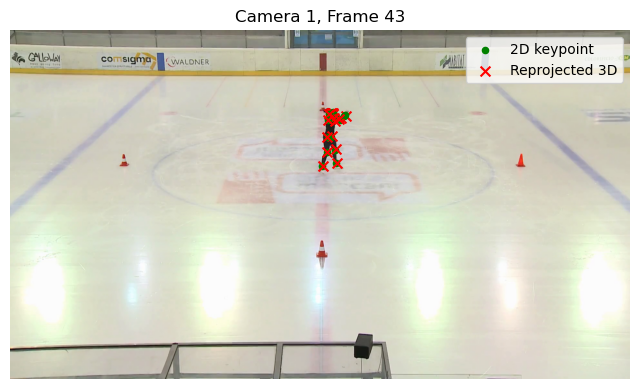

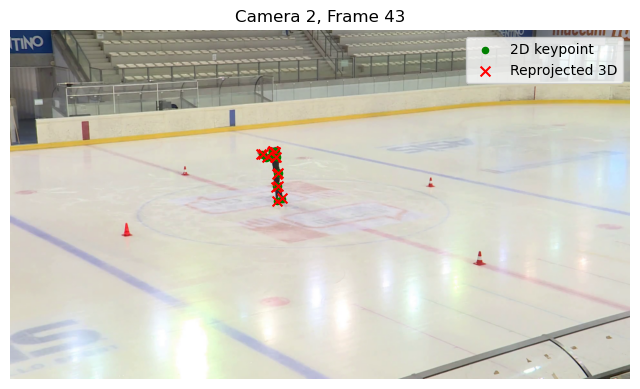

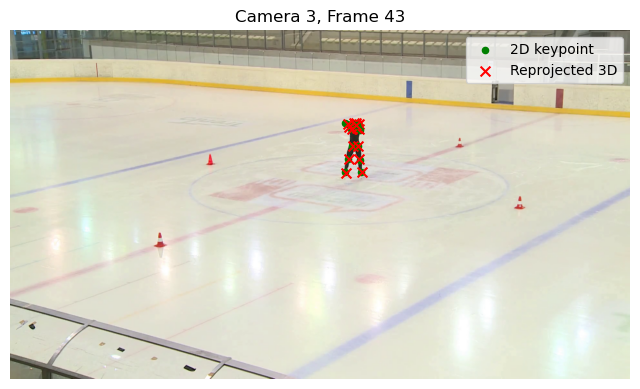

In [30]:
# reproject on frame 100th 
import cv2
import matplotlib.pyplot as plt 

path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

frame_idx = 43
frames_sample = []


for i, video_file in enumerate(video_files):
        cap = cv2.VideoCapture(video_file)
        
        # Set to the desired frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx} from camera {i}")
            frame = None
        frames_sample.append(frame)  # store the frame
        
        cap.release()
        if frame is not None:
            print(f"Camera {i}: grabbed frame {frame_idx}, shape: {frame.shape}")
for cam_idx in range(3):
        frame = frames_sample[cam_idx]
        if frame is None:
            continue
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        for j in range(17):
            # original 2D keypoint
            x2d = coords[cam_idx][frame_idx, j, :, 0]
            plt.scatter(x2d[0], x2d[1], c='g', s=20, label='2D keypoint' if j==0 else "")
            
            # reproject using anipose camera
            X3d = all_3d_interp[0,frame_idx, j, :]
            if np.any(np.isnan(X3d)):
                continue
            
            x_proj = cgroup.cameras[cam_idx].project(X3d.reshape(1, 3)).flatten()
            plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j==0 else "")

        plt.title(f"Camera {cam_idx+1}, Frame {frame_idx}")
        plt.legend(loc='upper right')
        plt.axis('off')
        plt.show()


In [33]:
from scipy.io import savemat
output_path = "/Volumes/THANH/IceSkating/models/3d_coords_floor_center.mat"

savemat(output_path,{"all_3d":all_3d_interp})

In [34]:
## cam1 coordinate

R_cam1, _ = cv2.Rodrigues(R1.reshape(3))
t_cam1 = t1.reshape(3)

all_3d_cam1 = all_3d_interp @ R_cam1.T + t_cam1

output_path = "/Volumes/THANH/IceSkating/models/3d_coords_cam1_center.mat"

savemat(output_path,{"all_3d_cam1":all_3d_cam1})

In [36]:
all_3d_interp

array([[[[-1.19187858, -1.558592  , -0.81634617],
         [-1.18098152, -1.59218279, -0.82245371],
         [-1.17656628, -1.58993826, -0.80018491],
         ...,
         [-1.0261202 , -0.59418026, -0.94621651],
         [-0.95733644, -0.19837976, -1.12921778],
         [-0.98627908, -0.17378171, -0.80577039]],

        [[-1.16381478, -1.5491999 , -0.80882113],
         [-1.15244643, -1.58296456, -0.81115867],
         [-1.14991665, -1.58001813, -0.79098509],
         ...,
         [-1.01768319, -0.58563191, -0.9112095 ],
         [-0.94601201, -0.19734512, -1.13517847],
         [-0.98316548, -0.17836001, -0.75671588]],

        [[-1.13438756, -1.54062668, -0.79906936],
         [-1.12250989, -1.57451751, -0.79879432],
         [-1.12130273, -1.57101677, -0.77983897],
         ...,
         [-1.00496715, -0.57770208, -0.87572843],
         [-0.93686888, -0.19559111, -1.13614084],
         [-0.97191112, -0.18220359, -0.70901266]],

        ...,

        [[-2.00055608, -1.33423458, -2

In [35]:
all_3d_cam1

array([[[[-1.10177225e+00, -1.80593053e+00,  2.26227516e+01],
         [-1.09096118e+00, -1.83642771e+00,  2.26073428e+01],
         [-1.08646218e+00, -1.84058192e+00,  2.26293185e+01],
         ...,
         [-9.34638546e-01, -8.44335633e-01,  2.27705141e+01],
         [-8.65753487e-01, -4.12978912e-01,  2.27067572e+01],
         [-8.93493993e-01, -4.80916980e-01,  2.30240518e+01]],

        [[-1.07366388e+00, -1.79907554e+00,  2.26325161e+01],
         [-1.06236841e+00, -1.83080699e+00,  2.26206719e+01],
         [-1.05976099e+00, -1.83369339e+00,  2.26408443e+01],
         ...,
         [-9.26060295e-01, -8.46052759e-01,  2.28064753e+01],
         [-8.54448459e-01, -4.10308656e-01,  2.27012883e+01],
         [-8.90213994e-01, -4.99195781e-01,  2.30697916e+01]],

        [[-1.04418572e+00, -1.79363737e+00,  2.26441789e+01],
         [-1.03237185e+00, -1.82622975e+00,  2.26348028e+01],
         [-1.03109033e+00, -1.82823859e+00,  2.26539689e+01],
         ...,
         [-9.13202524e-0